In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json

In [18]:
vis_objects = pd.read_csv('./dataset/vis_objects_set.csv')
vis_objects = vis_objects.iloc[:,1:] 

### Writing to csv

In [9]:
# remove first and last column with all nan
# # remove random spaces
# vis_objects.columns = vis_objects.columns.str.replace(' ','')
# vis_objects['alt_name'] = vis_objects['alt_name'].str.replace(' ','')
# vis_objects['vmag'] = pd.to_numeric(vis_objects['vmag'].str.replace(' ',''))
# vis_objects['multiple'] = vis_objects['multiple'].str.replace(' ','')
# vis_objects['class'] = vis_objects['class'].str.replace(' ','')
# vis_objects['parallax'] = pd.to_numeric(vis_objects['parallax'].str.replace(' ',''))

# def get_distance(starname):
#     try:
#         response = requests.get(f"http://localhost:8090/api/objects/info?name={starname}&format=json")
#         info = json.loads(response.text)
#         return info['distance-ly']
#     except:
#         return None
    
# vis_objects['distance'] = vis_objects[vis_objects['class'].str.contains('STAR')]['name'].apply(get_distance)
# vis_objects['absmag'] = vis_objects['vmag'] - 5 * np.log10(vis_objects['distance']) + 5

# vis_objects.to_csv('./dataset/vis_objects_set.csv')

In [ ]:
sorted_distance = vis_objects[~vis_objects['distance'].isna() & ~np.isinf(vis_objects['distance'])].sort_values(by='distance', ascending=True)

Calculations

In [ ]:
print(f'{round((vis_objects[vis_objects['multiple'].str.isalpha()].shape[0] / vis_objects.shape[0]) * 100, 2)}% of visible stars are multiples')

17.31% of visible stars are multiples


In [ ]:
starm_k = vis_objects[(vis_objects['class'].str.contains('STARM') | vis_objects['class'].str.contains('STARK'))]# & vis_objects['absmag'] < 0]
print(round((starm_k[starm_k['absmag'] < 0].shape[0] / vis_objects.shape[0])*100, 2))

27.5


In [ ]:
b = vis_objects['class'].apply(lambda starclass: starclass[4:5]).value_counts()
b.index

Index(['K', 'A', 'B', 'F', 'G', 'M', '', 'O', 'R', 'U', 'S'], dtype='object', name='class')

In [ ]:
print(sorted_distance[sorted_distance['multiple'].str.isalpha()].shape[0] / sorted_distance.shape[0])

0.17323182169259627


(array([102., 318., 434., 538., 472., 504., 486., 483., 541., 551., 515.,
        421., 328., 316., 261., 233., 185., 210., 174., 160., 123., 113.,
        135., 113.,  84.]),
 array([  4.39492774,  44.11593524,  83.83694275, 123.55795025,
        163.27895775, 202.99996525, 242.72097275, 282.44198025,
        322.16298776, 361.88399526, 401.60500276, 441.32601026,
        481.04701776, 520.76802526, 560.48903276, 600.21004027,
        639.93104777, 679.65205527, 719.37306277, 759.09407027,
        798.81507777, 838.53608528, 878.25709278, 917.97810028,
        957.69910778, 997.42011528]),
 <BarContainer object of 25 artists>)

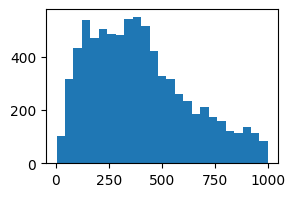

In [ ]:
star_distances_arr = sorted_distance[sorted_distance['distance'] < 1000]['distance'].to_numpy()

fig, ax = plt.subplots(1,1,figsize=(3,2))
ax.hist(star_distances_arr, bins=25)

In [ ]:
print(f'{(vis_objects[vis_objects['multiple'].str.isalpha()].shape[0] / vis_objects.shape[0]) * 100}% of visible stars are multiples')

17.31064763995609% of visible stars are multiples


In [ ]:
# select any region of sky and see what stars are there

In [72]:
def ra_to_degree(star):
    ls = star.split(' ')
    return 360/24*(float(ls[0]) + float(ls[1])/60 + float(ls[2])/3600)
def dec_to_degree(star):
    ls = star.split(' ')
    return (float(ls[0]) + np.sign(float(ls[0]))*float(float(ls[1]))/60 + np.sign(float(ls[0]))*float(ls[2])/3600)

new_star_df = vis_objects[['alt_name', 'ra', 'dec', 'distance', 'absmag']].copy()
new_star_df = new_star_df.loc[(new_star_df != 0).all(axis=1)].dropna(subset=['ra', 'dec', 'distance', 'absmag']) # drop zeroes and na
new_star_df.reset_index(drop=True, inplace=True)
new_star_df['ra'] = new_star_df['ra'].apply(ra_to_degree)
new_star_df['dec'] = new_star_df['dec'].apply(dec_to_degree)
new_star_df['sun_x'] = new_star_df['distance']*np.cos(new_star_df['dec']*np.pi/180)*np.cos(new_star_df['ra']*np.pi/180)
new_star_df['sun_y'] = new_star_df['distance']*np.cos(new_star_df['dec']*np.pi/180)*np.sin(new_star_df['ra']*np.pi/180)
new_star_df['sun_z'] = new_star_df['distance']*np.sin(new_star_df['dec']*np.pi/180)
star_choice = 'Alp1Cen'
new_star_index = new_star_df.loc[new_star_df['alt_name'] == star_choice].index[0]
new_star_df['star_x'] = new_star_df['sun_x'] - new_star_df.iloc[new_star_index]['sun_x']
new_star_df['star_y'] = new_star_df['sun_y'] - new_star_df.iloc[new_star_index]['sun_y']
new_star_df['star_z'] = new_star_df['sun_z'] - new_star_df.iloc[new_star_index]['sun_z']
new_star_df.drop(index=new_star_index, inplace=True) # drop the star itself
new_star_df.reset_index(drop=True, inplace=True)
new_star_df.loc[new_star_index]
new_star_df['star_dist'] = np.sqrt(new_star_df['star_x']**2 + new_star_df['star_y']**2 + new_star_df['star_z']**2) 
new_star_df['star_ra'] = (np.arctan2(new_star_df['star_y'], new_star_df['star_x']) + -1*(np.sign(np.arctan2(new_star_df['star_y'],new_star_df['star_x']))-1)*np.pi) * 180/np.pi 
new_star_df['star_dec'] = np.arcsin(new_star_df['star_z'] / new_star_df['star_dist']) * 180/np.pi
new_star_df['star_ap_mag'] = new_star_df['absmag'] + 5 * np.log10(new_star_df['star_dist'] / 10)

In [99]:
d = 2.512*(-northern_df['star_ap_mag'])
normd = (d-np.min(d))/(np.max(d)-np.min(d))

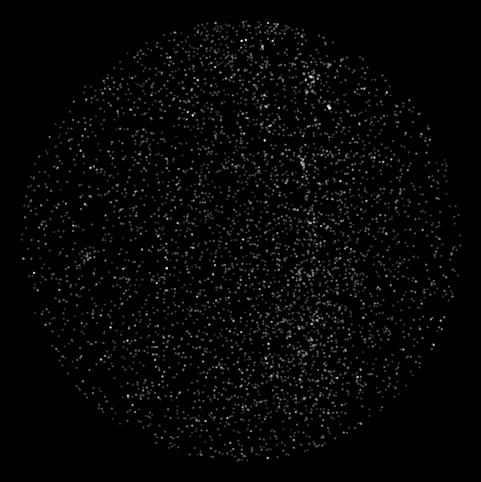

In [104]:
# drop any companion star
new_star_df = new_star_df.loc[new_star_df['star_ap_mag'] > -5]
# northern hemisphere
northern_df = new_star_df.loc[new_star_df['star_dec'] > 0]
theta, r = northern_df['star_ra']*np.pi/180, (90 - northern_df['star_dec'])*np.pi/180
norm_star_ap_mag = (northern_df['star_ap_mag'] - np.min(northern_df['star_ap_mag'])) / (np.max(northern_df['star_ap_mag']) - np.min(northern_df['star_ap_mag']))
fig = plt.figure(figsize=(8,8)) 
ax = fig.add_subplot(projection='polar')
ax.scatter(theta, r, c='white', s=0.5, alpha=normd)#s=norm_star_ap_mag,star_ap_mag)#size=np.log10(new_apparent_mag), alpha=)s=northern_df['star_ap_mag'],
fig.set_facecolor(color='black')
ax.set_facecolor(color='black')
ax.grid(False)
ax.set_xticklabels([])
ax.set_yticklabels([]);

In [20]:

ra_sun = vis_objects['ra'].apply(ra_to_degree).to_numpy()
dec_sun = vis_objects['dec'].apply(dec_to_degree).to_numpy()
dist_sun = vis_objects['distance'].to_numpy()
sun_arr = np.column_stack((ra_sun, dec_sun, dist_sun))
removed_indices = np.where(~(vis_objects[['ra', 'dec', 'distance', 'absmag']] == 0).any(axis=1) & ~np.isnan(sun_arr).any(axis=1))
sun_arr = sun_arr[removed_indices]
filt_vis_objects = vis_objects.iloc[removed_indices]
filt_vis_objects.reset_index(inplace=True)

ra_sun = sun_arr[:,0]
dec_sun = sun_arr[:,1]
dist_sun = sun_arr[:,2]

In [21]:
x_sun = dist_sun*np.cos(dec_sun*np.pi/180)*np.cos(ra_sun*np.pi/180)
y_sun = dist_sun*np.cos(dec_sun*np.pi/180)*np.sin(ra_sun*np.pi/180)
z_sun = dist_sun*np.sin(dec_sun*np.pi/180)

In [22]:
star_choice = 'Alp1Cen'
new_star_index = filt_vis_objects.loc[filt_vis_objects['alt_name'] == star_choice].index[0]
sun_coord_array = np.column_stack((x_sun,y_sun,z_sun))
new_star_coords = sun_coord_array[new_star_index]
new_coord_array = sun_coord_array - new_star_coords
removed_zero_indices = ~np.all(new_coord_array == 0, axis=1)
new_coord_array = new_coord_array[removed_zero_indices]
filt_vis_objects = filt_vis_objects[removed_zero_indices]

In [23]:
new_x, new_y, new_z = new_coord_array[:,0], new_coord_array[:,1], new_coord_array[:,2]
new_dists = np.sqrt(new_x**2 + new_y**2 + new_z**2)
new_ra = (np.arctan2(new_y, new_x) + -1*(np.sign(np.arctan2(new_y,new_x))-1)*np.pi) * 180/np.pi 
new_dec = np.arcsin(new_z / new_dists) * 180/np.pi
new_star_polar = np.column_stack((new_ra, new_dec, new_dists))

In [27]:
new_apparent_mag = filt_vis_objects['absmag'] + 5 * np.log10(new_dists / 10)

In [25]:
# remove binary star companion, only run if there is one
new_apparent_mag = np.delete(new_apparent_mag, np.where(new_apparent_mag != np.min(new_apparent_mag))[0])
new_star_polar = np.delete(new_star_polar, np.where(new_apparent_mag != np.min(new_apparent_mag))[0])
new_ra, new_dec, new_dist = new_star_polar[:,0], new_star_polar[:,1], new_star_polar[:,2]

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
norm_new_mag = (new_apparent_mag - np.min(new_apparent_mag)) / (np.max(new_apparent_mag) - np.min(new_apparent_mag))

IndexError: boolean index did not match indexed array along axis 0; size of axis is 9063 but size of corresponding boolean axis is 9062

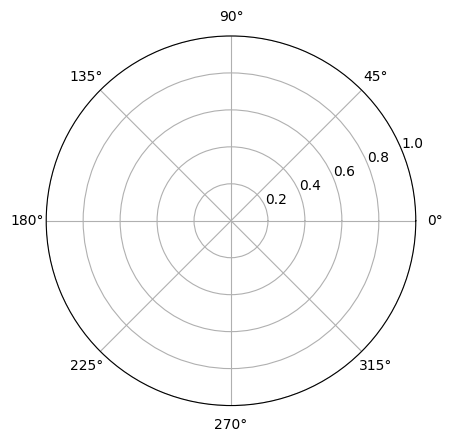

In [ ]:
# northern hemisphere
fig = plt.figure() 
ax = fig.add_subplot(projection='polar')
northern_stars = new_dec > 0
theta, r = ra_sun[northern_stars]*np.pi/180, (90 - dec_sun[northern_stars])*np.pi/180
norm_new_mag = new_apparent_mag[northern_stars]
new_apparent_mag = new_apparent_mag[northern_stars]
ax.scatter(theta, r, s=new_apparent_mag, alpha=norm_new_mag)#size=np.log10(new_apparent_mag), alpha=)
